100%|██████████| 170M/170M [00:06<00:00, 25.7MB/s]



Training with lambda = 0.001
Epoch 1, Loss: 1.8701
Epoch 2, Loss: 1.6887
Epoch 3, Loss: 1.5998
Epoch 4, Loss: 1.5333
Epoch 5, Loss: 1.4899
Epoch 6, Loss: 1.4504
Epoch 7, Loss: 1.4237
Epoch 8, Loss: 1.3895
Epoch 9, Loss: 1.3659
Epoch 10, Loss: 1.3369
Accuracy: 0.4979, Sparsity: 1.53%

Training with lambda = 0.01
Epoch 1, Loss: 1.9026
Epoch 2, Loss: 1.7053
Epoch 3, Loss: 1.6116
Epoch 4, Loss: 1.5508
Epoch 5, Loss: 1.5031
Epoch 6, Loss: 1.4638
Epoch 7, Loss: 1.4260
Epoch 8, Loss: 1.3988
Epoch 9, Loss: 1.3722
Epoch 10, Loss: 1.3468
Accuracy: 0.4945, Sparsity: 2.05%

Training with lambda = 0.1
Epoch 1, Loss: 1.9374
Epoch 2, Loss: 1.7425
Epoch 3, Loss: 1.6589
Epoch 4, Loss: 1.5902
Epoch 5, Loss: 1.5409
Epoch 6, Loss: 1.4973
Epoch 7, Loss: 1.4617
Epoch 8, Loss: 1.4279
Epoch 9, Loss: 1.4012
Epoch 10, Loss: 1.3696
Accuracy: 0.4999, Sparsity: 20.47%


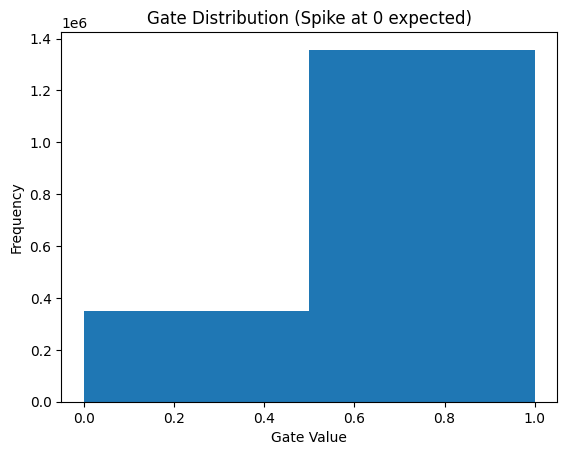


Final Results:
Lambda: 0.001, Accuracy: 0.4979, Sparsity: 1.53%
Lambda: 0.01, Accuracy: 0.4945, Sparsity: 2.05%
Lambda: 0.1, Accuracy: 0.4999, Sparsity: 20.47%


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)


        hard_gates = (gates > 0.1).float()


        gates = gates + (hard_gates - gates).detach()

        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def sparsity_loss(model):
    loss = 0
    total = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
            total += gates.numel()

    return loss / total   # VERY IMPORTANT


def train(model, loader, optimizer, lambda_val):
    model.train()
    total_loss = 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        output = model(data)
        ce_loss = F.cross_entropy(output, target)
        sp_loss = sparsity_loss(model)

        loss = ce_loss + lambda_val * sp_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def test(model, loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    return correct / len(loader.dataset)


def calculate_sparsity(model, threshold=0.1):
    total = 0
    zero = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            zero += (gates < threshold).sum().item()

    return 100 * zero / total


transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128)


lambdas = [0.001, 0.01, 0.1]
results = []

best_model = None
best_acc = 0

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(10):   # more epochs for better pruning
        loss = train(model, train_loader, optimizer, lam)
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    acc = test(model, test_loader)
    sparsity = calculate_sparsity(model)

    print(f"Accuracy: {acc:.4f}, Sparsity: {sparsity:.2f}%")

    results.append((lam, acc, sparsity))

    if acc > best_acc:
        best_acc = acc
        best_model = model


all_gates = []

for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores)
        hard_gates = (gates > 0.1).float()
        all_gates.extend(hard_gates.cpu().detach().numpy().flatten())

plt.hist(all_gates, bins=2)
plt.title("Gate Distribution (Spike at 0 expected)")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()


print("\nFinal Results:")
for lam, acc, sp in results:
    print(f"Lambda: {lam}, Accuracy: {acc:.4f}, Sparsity: {sp:.2f}%")